In [1]:
import torch
import matplotlib.pyplot as plt
import gymnasium as gym
import r2l
import rl_utils
import random
import numpy as np

# 连续动作空间

In [ ]:

env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0] # 动作最大值
random.seed(0)
np.random.seed(0)
env.reset(seed=0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = r2l.get_gpu()

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = r2l.SACContinuous(state_dim, hidden_dim, action_dim, action_bound, actor_lr, critic_lr, alpha_lr, target_entropy, tau, gamma, device )

In [3]:
return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes, replay_buffer, minimal_size, batch_size)

Iteration 9: 100%|██████████| 10/10 [00:04<00:00,  2.25it/s, episode=100, return=-179.009]


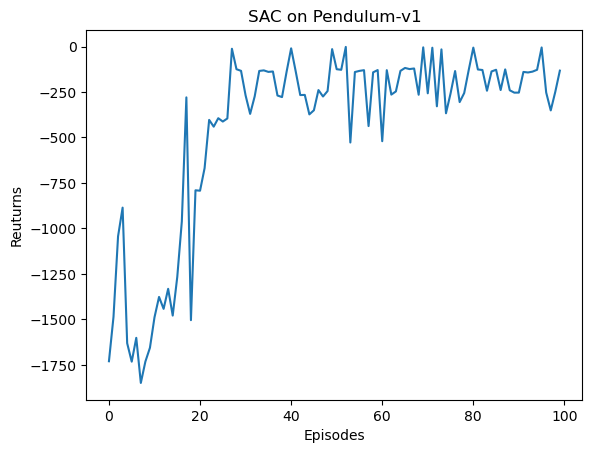

In [4]:
episodes_lsit = list(range(len(return_list)))
plt.plot(episodes_lsit, return_list)
plt.xlabel('Episodes')
plt.ylabel('Reuturns')
plt.title('SAC on {}'.format(env_name))
plt.show()

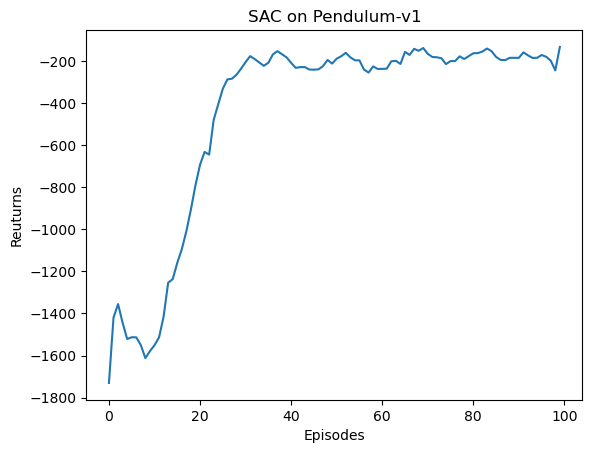

In [5]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_lsit, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Reuturns")
plt.title("SAC on {}".format(env_name))
plt.show()

# 离散动作空间

In [13]:
env_name = "CartPole-v0"
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
random.seed(0)
np.random.seed(0)
env.reset(seed=0)
torch.manual_seed(1)

actor_lr = 1e-3
critic_lr = 1e-2
alpha_lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
tau = 0.005
buffer_size = 10000
minimal_size = 500
batch_size = 64
target_entropy = -1
device = r2l.get_gpu()

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = r2l.SAC(
    state_dim,
    hidden_dim,
    action_dim,
    actor_lr,
    critic_lr,
    alpha_lr,
    target_entropy,
    tau,
    gamma,
    device,
)

In [14]:
return_list = rl_utils.train_off_policy_agent(
    env, agent, num_episodes, replay_buffer, minimal_size, batch_size
)

Iteration 9: 100%|██████████| 20/20 [00:13<00:00,  1.48it/s, episode=200, return=194.500]


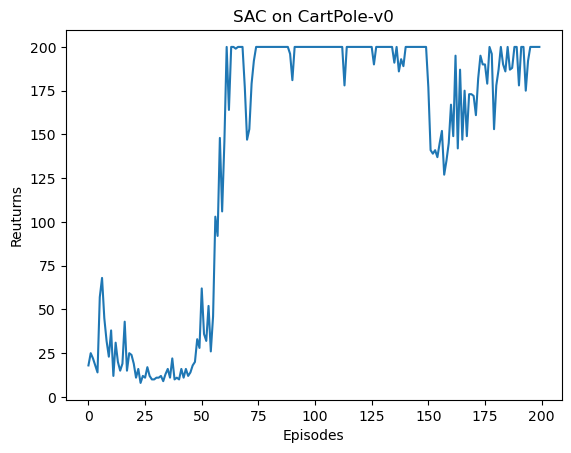

In [15]:
episodes_lsit = list(range(len(return_list)))
plt.plot(episodes_lsit, return_list)
plt.xlabel("Episodes")
plt.ylabel("Reuturns")
plt.title("SAC on {}".format(env_name))
plt.show()

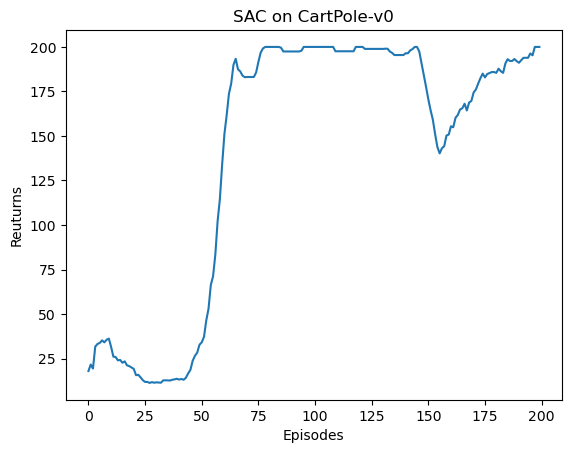

In [16]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_lsit, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Reuturns")
plt.title("SAC on {}".format(env_name))
plt.show()